# Object Detection Project
## Russian License Plate Blurring

**Name :** MITHUN KUMAR G   **Reg. No :** 212224230160    **Slot No :** T2-J6


In [24]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [25]:
img = cv2.imread("car_plate.jpg")
img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

In [26]:
def display(img):

    plt.figure(figsize=(10,8))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

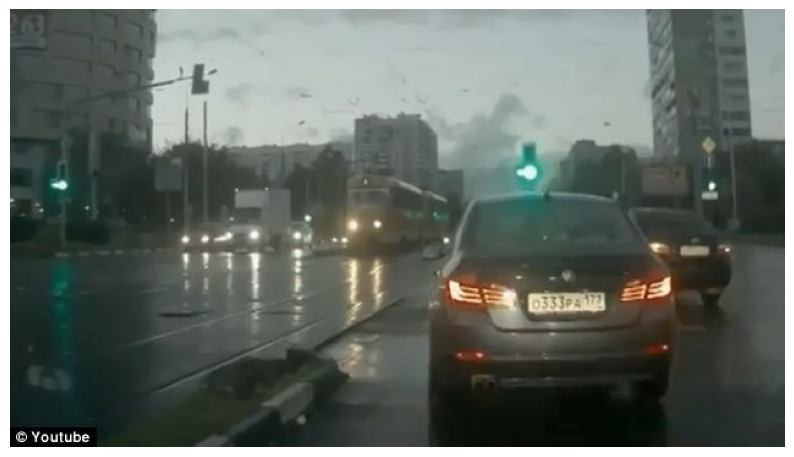

In [27]:
display(img)

In [28]:
plate_cascade = cv2.CascadeClassifier("haarcascade_licence_plate_rus_16stages.xml")

In [29]:
def detect_plate(img):

    plate_img = img.copy()

    plate_rects = plate_cascade.detectMultiScale(
        plate_img,
        scaleFactor=1.1,
        minNeighbors=5
    )

    for (x,y,w,h) in plate_rects:

        cv2.rectangle(
            plate_img,
            (x,y),
            (x+w,y+h),
            (255,0,0),
            3
        )

    return plate_img

In [30]:
result = detect_plate(img)

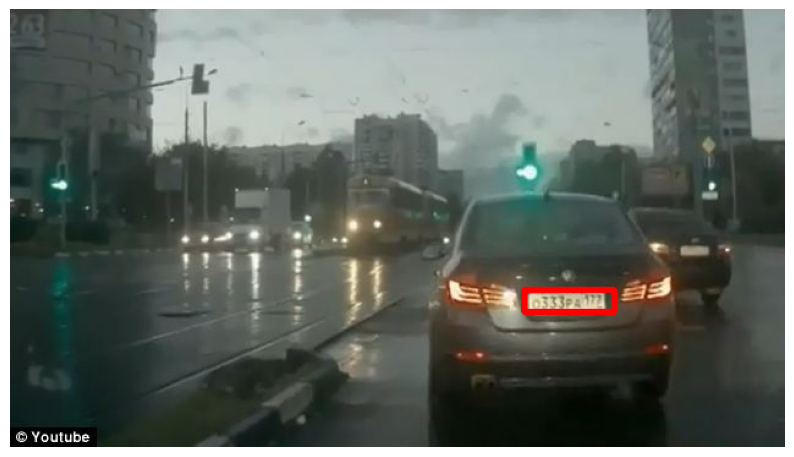

In [31]:
display(result)

In [32]:
def detect_and_blur_plate(img):

    plate_img = img.copy()

    plate_rects = plate_cascade.detectMultiScale(
        plate_img,
        scaleFactor=1.1,
        minNeighbors=5
    )

    for (x,y,w,h) in plate_rects:

        # Extract ROI
        roi = plate_img[
            y:y+h,
            x:x+w
        ]

        # Blur the ROI
        blurred_roi = cv2.medianBlur(
            roi,
            35
        )

        # Replace original ROI with blurred ROI
        plate_img[
            y:y+h,
            x:x+w
        ] = blurred_roi

    return plate_img

In [33]:
result = detect_and_blur_plate(img)

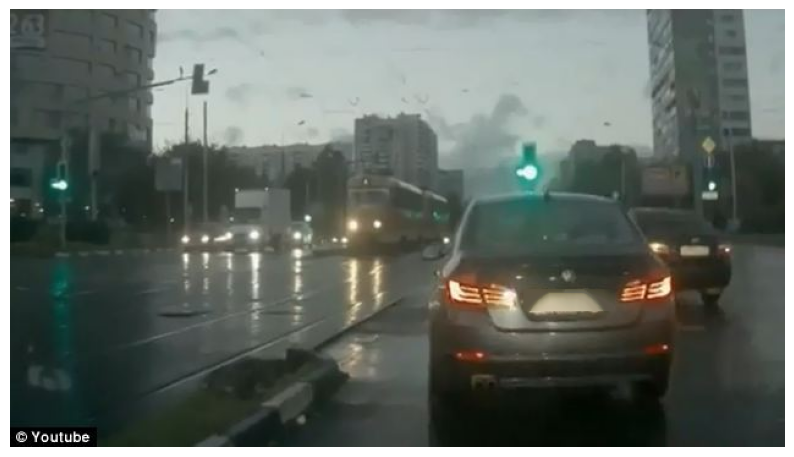

In [34]:
display(result)